# RT-IoT2022 Real-Time IoT Network Traffic — LWCE Loss Comparison

PyTorch MLP on RT-IoT2022 (multi-class: normal IoT traffic + attack types).
Comparing 7 loss functions: `ce`, `wce`, `pwce`, `lwce`, `plwce`, `cb`, `focal`.

In [3]:
!pip install -q torch torchvision optuna pandas openpyxl scikit-learn kagglehub

import os, sys, gc, json, warnings, importlib.util, glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import GridSampler

warnings.filterwarnings('ignore')

REPO_PATH = '/content/imbalanced-data-LWCE'
if not os.path.exists(REPO_PATH):
    print('Cloning...')
    !git clone https://github.com/gseungho/imbalanced-data-LWCE.git {REPO_PATH}

get_clf_loss = None
try:
    spec = importlib.util.spec_from_file_location(
        'clf', f'{REPO_PATH}/image_classification/custom_losses.py'
    )
    clf_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(clf_module)
    get_clf_loss = clf_module.get_clf_loss
    print('✓ Loss functions loaded!')
except Exception as e:
    print(f'Warning: {e}')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Kaggle dataset ID: 'supplejade/rt-iot2022real-time-internet-of-things'
# CSV 파일 1개, 85 columns

DATASET_NAME       = 'RT-IoT2022'
BATCH_SIZE         = 512
FINAL_EPOCHS       = 50
PROXY_EPOCHS       = 10
PROXY_SUBSET_RATIO = 0.20
TARGET_TOTAL       = 300_000
BENIGN_MAX         = 100_000
RESULTS_DIR = '/content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/RT-IoT2022'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'Results dir: {RESULTS_DIR}')

✓ Loss functions loaded!
Device: cuda
Results dir: /content/gdrive/MyDrive/imbalanced-data-LWCE/network_data/results/RT-IoT2022


In [4]:
def _stratified_subset(df, label_col, target_total, benign_max):
    unique_labels = df[label_col].unique()
    normal_label  = next((l for l in unique_labels
                          if 'normal' in l.lower() or 'benign' in l.lower()), None)
    non_budget    = target_total - (benign_max if normal_label else 0)
    non_total     = (df[label_col] != normal_label).sum() if normal_label else len(df)
    idx_list = []
    for lbl in unique_labels:
        idx = df.index[df[label_col] == lbl].tolist()
        if normal_label and lbl == normal_label:
            take = min(len(idx), benign_max)
        else:
            prop = len(idx) / max(non_total, 1)
            take = max(50, min(len(idx), int(prop * non_budget)))
        idx_list.extend(np.random.choice(idx, min(take, len(idx)), replace=False).tolist())
    return df.loc[idx_list].reset_index(drop=True)


def make_loaders(X_tr, X_val, X_te, y_tr, y_val, y_te, batch_size):
    def ds(X, y):
        return TensorDataset(torch.tensor(X, dtype=torch.float32),
                             torch.tensor(y, dtype=torch.long))
    train_loader = DataLoader(ds(X_tr,  y_tr),  batch_size=batch_size, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(ds(X_val, y_val), batch_size=batch_size, shuffle=False, num_workers=0)
    test_loader  = DataLoader(ds(X_te,  y_te),  batch_size=batch_size, shuffle=False, num_workers=0)
    return train_loader, val_loader, test_loader

# Cell 1: Load & Preprocess RT-IoT2022
import kagglehub

def load_rtiot2022():
    print('Downloading RT-IoT2022...')
    path = kagglehub.dataset_download('supplejade/rt-iot2022real-time-internet-of-things')
    print(f'Dataset path: {path}')

    csv_files = sorted(glob.glob(f'{path}/**/*.csv', recursive=True))
    if not csv_files:
        raise FileNotFoundError(f'No CSV files found in {path}')
    print(f'Loading {len(csv_files)} CSV file(s)...')
    dfs = []
    for f in csv_files:
        try:
            df_part = pd.read_csv(f, encoding='utf-8', low_memory=False)
        except UnicodeDecodeError:
            df_part = pd.read_csv(f, encoding='latin-1', low_memory=False)
        dfs.append(df_part)
        print(f'  {os.path.basename(f)}: {len(df_part):,} rows')
    df = pd.concat(dfs, axis=0, ignore_index=True)
    print(f'\nTotal rows: {len(df):,}')
    print(f'Columns: {df.columns.tolist()}')

    # RT-IoT2022 'Attack_type' 컬럼 우선
    LABEL_PRIORITY = ['Attack_type', 'attack_type', 'Attack_Type',
                      'type', 'Type', 'Label', 'label',
                      'category', 'attack', 'class']
    label_col = None
    for c in LABEL_PRIORITY:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        label_col = df.columns[-1]
        print(f'Warning: using last column as label: {label_col!r}')
    print(f'\nUsing label column: {label_col!r}')
    df['label'] = df[label_col].astype(str).str.strip()
    print(f'Unique labels ({df["label"].nunique()}): {sorted(df["label"].unique())}')

    feature_cols = [c for c in df.columns if c not in [label_col, 'label']]
    df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
    before = len(df)
    df = df.dropna(subset=feature_cols)
    print(f'Dropped {before - len(df):,} rows with inf/NaN')
    num_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    print(f'Numeric features: {len(num_cols)}')

    if len(df) > TARGET_TOTAL:
        print(f'Dataset size {len(df):,} > TARGET_TOTAL={TARGET_TOTAL:,}; subsampling...')
        df_sub = _stratified_subset(df, 'label', TARGET_TOTAL, BENIGN_MAX)
    else:
        df_sub = df.copy()
        print(f'Using full dataset: {len(df_sub):,} rows')

    le = LabelEncoder()
    df_sub['class'] = le.fit_transform(df_sub['label'])
    class_names_enc = le.classes_.tolist()
    num_cls         = len(class_names_enc)
    print(f'Classes ({num_cls}): {class_names_enc}')

    X = df_sub[num_cols].values.astype(np.float32)
    y = df_sub['class'].values.astype(np.int64)

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=42
    )
    X_val, X_te, y_val, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42
    )
    scaler = StandardScaler()
    X_tr  = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)
    X_te  = scaler.transform(X_te)

    class_counts = [int((y_tr == i).sum()) for i in range(num_cls)]
    input_dim    = X_tr.shape[1]
    print(f'\n✓ Loaded: Train={len(X_tr):,}, Val={len(X_val):,}, Test={len(X_te):,}')
    print(f'Input dim: {input_dim}')
    print('\nClass distribution (train):')
    for i, (name, cnt) in enumerate(zip(class_names_enc, class_counts)):
        pct = cnt / sum(class_counts) * 100
        print(f'  {i:2d} {name:35s}: {cnt:6,d} ({pct:.2f}%)')
    ir = max(class_counts) / max(min(c for c in class_counts if c > 0), 1)
    print(f'Imbalance ratio: {ir:.0f}:1')
    return (X_tr, X_val, X_te, y_tr, y_val, y_te,
            class_counts, input_dim, class_names_enc, num_cls)


(X_tr, X_val, X_te, y_tr, y_val, y_te,
 class_counts, INPUT_DIM, CLASS_NAMES, NUM_CLASSES) = load_rtiot2022()
train_loader, val_loader, test_loader = make_loaders(
    X_tr, X_val, X_te, y_tr, y_val, y_te, BATCH_SIZE
)

100%|██████████| 3.64M/3.64M [00:00<00:00, 139MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/supplejade/rt-iot2022real-time-internet-of-things/versions/3
Loading 1 CSV file(s)...
  RT_IOT2022.csv: 123,117 rows

Total rows: 123,117
Columns: ['no', 'id.orig_p', 'id.resp_p', 'proto', 'service', 'flow_duration', 'fwd_pkts_tot', 'bwd_pkts_tot', 'fwd_data_pkts_tot', 'bwd_data_pkts_tot', 'fwd_pkts_per_sec', 'bwd_pkts_per_sec', 'flow_pkts_per_sec', 'down_up_ratio', 'fwd_header_size_tot', 'fwd_header_size_min', 'fwd_header_size_max', 'bwd_header_size_tot', 'bwd_header_size_min', 'bwd_header_size_max', 'flow_FIN_flag_count', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'flow_ACK_flag_count', 'fwd_URG_flag_count', 'bwd_URG_flag_count', 'flow_CWR_flag_count', 'flow_ECE_flag_count', 'fwd_pkts_payload.min', 'fwd_pkts_payload.max', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.avg', 'fwd_pkts_payload.std', 'bwd_pkts_payload.min', 'bwd_pkts_payload.max', 'bwd_pkts_payload.tot', 'bwd_pkts_payload.avg', 'bwd_

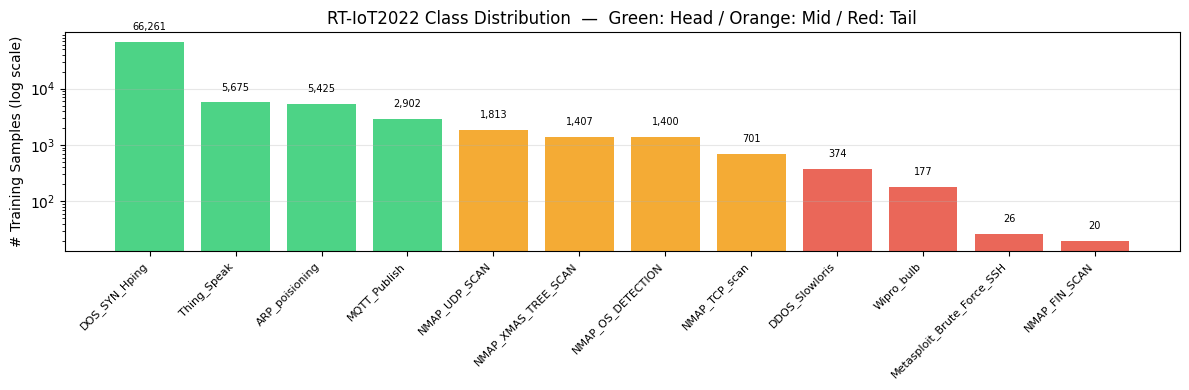

Head (≥2096): 4 classes
Mid  (580–2096): 4 classes
Tail (<580): 4 classes


In [5]:
# Cell 2: Class Distribution Visualization
def visualize_distribution(class_counts, class_names, title, save_path):
    counts = np.array(class_counts)
    order  = np.argsort(counts)[::-1]
    q1, q3 = np.percentile(counts, [33, 66])
    colors = ['#2ecc71' if c >= q3 else '#f39c12' if c >= q1 else '#e74c3c'
              for c in counts[order]]
    fig, ax = plt.subplots(figsize=(max(12, len(class_names)), 4))
    ax.bar(range(len(class_names)), counts[order], color=colors, alpha=0.85)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels([class_names[i] for i in order],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yscale('log')
    ax.set_ylabel('# Training Samples (log scale)')
    ax.set_title(f'{title}  —  Green: Head / Orange: Mid / Red: Tail')
    ax.grid(True, alpha=0.3, axis='y')
    for i, c in enumerate(counts[order]):
        ax.text(i, c * 1.5, f'{c:,}', ha='center', va='bottom', fontsize=7)
    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    q1_val, q3_val = np.percentile(counts, [33, 66])
    head = sum(1 for c in counts if c >= q3_val)
    mid  = sum(1 for c in counts if q1_val <= c < q3_val)
    tail = sum(1 for c in counts if c < q1_val)
    print(f'Head (≥{q3_val:.0f}): {head} classes')
    print(f'Mid  ({q1_val:.0f}–{q3_val:.0f}): {mid} classes')
    print(f'Tail (<{q1_val:.0f}): {tail} classes')

visualize_distribution(
    class_counts, CLASS_NAMES,
    f'{DATASET_NAME} Class Distribution',
    f'{RESULTS_DIR}/class_distribution.png'
)

In [6]:
# Cell 3: MLP Model + Evaluation Functions

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes,
                 hidden_dims=(256, 128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def build_mlp():
    return MLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)


def compute_metrics(model, loader, class_counts):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            preds = model(X_b.to(DEVICE)).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_b.numpy())
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    labels = list(range(NUM_CLASSES))
    per_f1 = f1_score(y_true, y_pred, average=None, labels=labels, zero_division=0)
    counts = np.array(class_counts)
    q1, q3 = np.percentile(counts, [33, 66])
    head_idx = [i for i in range(NUM_CLASSES) if counts[i] >= q3]
    mid_idx  = [i for i in range(NUM_CLASSES) if q1 <= counts[i] < q3]
    tail_idx = [i for i in range(NUM_CLASSES) if counts[i] < q1]
    return {
        'Accuracy':          float(accuracy_score(y_true, y_pred)),
        'Balanced_Accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'F1_Macro':          float(f1_score(y_true, y_pred, average='macro',    zero_division=0)),
        'F1_Weighted':       float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
        'Per_Class_F1':      per_f1.tolist(),
        'Head_F1': float(per_f1[head_idx].mean()) if head_idx else 0.0,
        'Mid_F1':  float(per_f1[mid_idx].mean())  if mid_idx  else 0.0,
        'Tail_F1': float(per_f1[tail_idx].mean()) if tail_idx else 0.0,
    }

print('✓ MLP and evaluation functions defined')

✓ MLP and evaluation functions defined


In [7]:
# Cell 4: train_model() — definition only, not executed here

def train_model(loss_name, class_counts, tr_loader, val_loader,
                alpha=1.0, gamma=2.0, epochs=FINAL_EPOCHS):
    model = build_mlp()
    if get_clf_loss is not None:
        criterion = get_clf_loss(loss_name, class_counts, alpha=alpha, gamma=gamma)
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', patience=5, factor=0.5, min_lr=1e-6
    )
    history       = {'train_loss': [], 'val_F1_Macro': []}
    best_F1_Macro = 0.0
    best_state    = None
    print(f"\n{'='*50}\nTraining {loss_name.upper()} (α={alpha:.2f}, γ={gamma:.2f})\n{'='*50}")
    for epoch in range(epochs):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for X_b, y_b in tr_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits   = model(X_b)
            loss     = criterion(logits, y_b)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            n_batches  += 1
        avg_loss = epoch_loss / max(n_batches, 1)
        history['train_loss'].append(avg_loss)
        metrics  = compute_metrics(model, val_loader, class_counts)
        f1_macro = metrics['F1_Macro']
        history['val_F1_Macro'].append(f1_macro)
        scheduler.step(f1_macro)
        if f1_macro > best_F1_Macro:
            best_F1_Macro = f1_macro
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
            print(f'Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | F1-Macro: {f1_macro:.4f}')
    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    print(f'✓ {loss_name.upper()} best F1-Macro: {best_F1_Macro:.4f}')
    return model, history, best_F1_Macro

print('✓ train_model defined (not executed yet)')

✓ train_model defined (not executed yet)


In [8]:
# Cell 5: Optuna Hyperparameter Search
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ['TQDM_DISABLE'] = '1'

def _make_proxy_loader(ratio=PROXY_SUBSET_RATIO):
    n   = int(len(train_loader.dataset) * ratio)
    idx = np.random.choice(len(train_loader.dataset), n, replace=False)
    return DataLoader(Subset(train_loader.dataset, idx),
                     batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

def _cleanup(model=None):
    if model is not None:
        del model
    gc.collect()
    torch.cuda.empty_cache()

print(f'Optuna search (proxy: {PROXY_EPOCHS} epochs, {PROXY_SUBSET_RATIO*100:.0f}% subset)\n')
optuna_best  = {}
proxy_loader = _make_proxy_loader()

N_PWCE = 20
study_pwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(0.5, 5.0, N_PWCE).tolist()})
)
def obj_pwce(trial):
    alpha = trial.suggest_float('alpha', 0.5, 5.0)
    model, _, score = train_model('pwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_pwce.optimize(obj_pwce, n_trials=N_PWCE)
best_pwce = study_pwce.best_params
optuna_best['pwce'] = best_pwce
print(f'✓ PWCE  best: alpha={best_pwce["alpha"]:.2f}  (F1-Macro={study_pwce.best_value:.4f})')

N_PLWCE = 20
study_plwce = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'alpha': np.linspace(1.0, 10.0, N_PLWCE).tolist()})
)
def obj_plwce(trial):
    alpha = trial.suggest_float('alpha', 1.0, 10.0)
    model, _, score = train_model('plwce', class_counts, proxy_loader, val_loader,
                                  alpha=alpha, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_plwce.optimize(obj_plwce, n_trials=N_PLWCE)
best_plwce = study_plwce.best_params
optuna_best['plwce'] = best_plwce
print(f'✓ PLWCE best: alpha={best_plwce["alpha"]:.2f}  (F1-Macro={study_plwce.best_value:.4f})')

N_FOCAL = 20
study_focal = optuna.create_study(
    direction='maximize',
    sampler=GridSampler({'gamma': np.linspace(0.5, 5.0, N_FOCAL).tolist()})
)
def obj_focal(trial):
    gamma = trial.suggest_float('gamma', 0.5, 5.0)
    model, _, score = train_model('focal', class_counts, proxy_loader, val_loader,
                                  gamma=gamma, epochs=PROXY_EPOCHS)
    _cleanup(model)
    return score if score is not None else 0.0
study_focal.optimize(obj_focal, n_trials=N_FOCAL)
best_focal = study_focal.best_params
optuna_best['focal'] = best_focal
print(f'✓ FOCAL best: gamma={best_focal["gamma"]:.2f}  (F1-Macro={study_focal.best_value:.4f})')

print(f'\nOptuna Results:\n{json.dumps(optuna_best, indent=2)}')

Optuna search (proxy: 10 epochs, 20% subset)


Training PWCE (α=4.76, γ=2.00)
Epoch 10/10 | Loss: 0.0933 | F1-Macro: 0.2187
✓ PWCE best F1-Macro: 0.2385

Training PWCE (α=0.74, γ=2.00)
Epoch 10/10 | Loss: 0.2164 | F1-Macro: 0.8702
✓ PWCE best F1-Macro: 0.8702

Training PWCE (α=5.00, γ=2.00)
Epoch 10/10 | Loss: 0.0618 | F1-Macro: 0.1297
✓ PWCE best F1-Macro: 0.1775

Training PWCE (α=2.39, γ=2.00)
Epoch 10/10 | Loss: 0.2905 | F1-Macro: 0.4349
✓ PWCE best F1-Macro: 0.4990

Training PWCE (α=2.87, γ=2.00)
Epoch 10/10 | Loss: 0.1363 | F1-Macro: 0.2875
✓ PWCE best F1-Macro: 0.2954

Training PWCE (α=4.53, γ=2.00)
Epoch 10/10 | Loss: 0.1922 | F1-Macro: 0.2198
✓ PWCE best F1-Macro: 0.2336

Training PWCE (α=1.92, γ=2.00)
Epoch 10/10 | Loss: 0.2821 | F1-Macro: 0.4540
✓ PWCE best F1-Macro: 0.4986

Training PWCE (α=3.58, γ=2.00)
Epoch 10/10 | Loss: 0.1241 | F1-Macro: 0.3707
✓ PWCE best F1-Macro: 0.3707

Training PWCE (α=1.45, γ=2.00)
Epoch 10/10 | Loss: 0.2293 | F1-Macro: 0.8336
✓ PWCE best F1-Macro

In [9]:
# Cell 6: Full Experiment (N_SEEDS seeds)
import random

N_SEEDS       = 5
LOSS_CONFIGS  = ['ce', 'wce', 'pwce', 'lwce', 'plwce', 'cb', 'focal']
seed_results   = {ln: [] for ln in LOSS_CONFIGS}
seed_histories = {ln: [] for ln in LOSS_CONFIGS}

print(f"\n{'='*60}")
print(f'FULL EXPERIMENT: {FINAL_EPOCHS} epochs × {len(LOSS_CONFIGS)} losses × {N_SEEDS} seeds')
print(f"{'='*60}")

for seed in range(N_SEEDS):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    print(f"\n{'─'*25}  Seed {seed}  {'─'*25}")
    for loss_name in LOSS_CONFIGS:
        alpha = optuna_best.get(loss_name, {}).get('alpha', 1.0)
        gamma = optuna_best.get('focal', {}).get('gamma', 2.0) if loss_name == 'focal' else 2.0
        model, history, _ = train_model(
            loss_name, class_counts, train_loader, val_loader,
            alpha=alpha, gamma=gamma, epochs=FINAL_EPOCHS
        )
        metrics = compute_metrics(model, test_loader, class_counts)
        seed_results[loss_name].append(metrics)
        seed_histories[loss_name].append(history)
        _cleanup(model)

print(f"\n{'='*60}")
print('✓ Full experiment completed!')
print(f"{'='*60}")


FULL EXPERIMENT: 50 epochs × 7 losses × 5 seeds

─────────────────────────  Seed 0  ─────────────────────────

Training CE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.0262 | F1-Macro: 0.9455
Epoch 20/50 | Loss: 0.0176 | F1-Macro: 0.9482
Epoch 30/50 | Loss: 0.0169 | F1-Macro: 0.9483
Epoch 40/50 | Loss: 0.0133 | F1-Macro: 0.9419
Epoch 50/50 | Loss: 0.0126 | F1-Macro: 0.9483
✓ CE best F1-Macro: 0.9498

Training WCE (α=1.00, γ=2.00)
Epoch 10/50 | Loss: 0.1714 | F1-Macro: 0.8922
Epoch 20/50 | Loss: 0.1226 | F1-Macro: 0.9032
Epoch 30/50 | Loss: 0.1215 | F1-Macro: 0.9158
Epoch 40/50 | Loss: 0.0982 | F1-Macro: 0.9111
Epoch 50/50 | Loss: 0.1184 | F1-Macro: 0.9131
✓ WCE best F1-Macro: 0.9288

Training PWCE (α=0.50, γ=2.00)
Epoch 10/50 | Loss: 0.0797 | F1-Macro: 0.9296
Epoch 20/50 | Loss: 0.0620 | F1-Macro: 0.9159
Epoch 30/50 | Loss: 0.0493 | F1-Macro: 0.9414
Epoch 40/50 | Loss: 0.0432 | F1-Macro: 0.9224
Epoch 50/50 | Loss: 0.0437 | F1-Macro: 0.9413
✓ PWCE best F1-Macro: 0.9493

Training LWCE (α=1.00


EXPERIMENT SUMMARY (mean ± std, N=5)
Loss                Bal_Acc           F1_Macro            Head_F1            Tail_F1
ce            0.9491±0.0020      0.9574±0.0010      0.9871±0.0028      0.8957±0.0029
wce           0.9653±0.0016      0.9288±0.0032      0.9832±0.0024      0.8158±0.0070
pwce          0.9675±0.0016      0.9565±0.0057      0.9867±0.0024      0.8955±0.0178
lwce          0.9560±0.0029      0.9632±0.0050      0.9895±0.0010      0.9105±0.0141
plwce         0.9588±0.0045      0.9606±0.0068      0.9890±0.0010      0.9037±0.0197
cb            0.9618±0.0028      0.9350±0.0125      0.9788±0.0051      0.8417±0.0340
focal         0.9554±0.0044      0.9612±0.0051      0.9876±0.0009      0.9068±0.0143


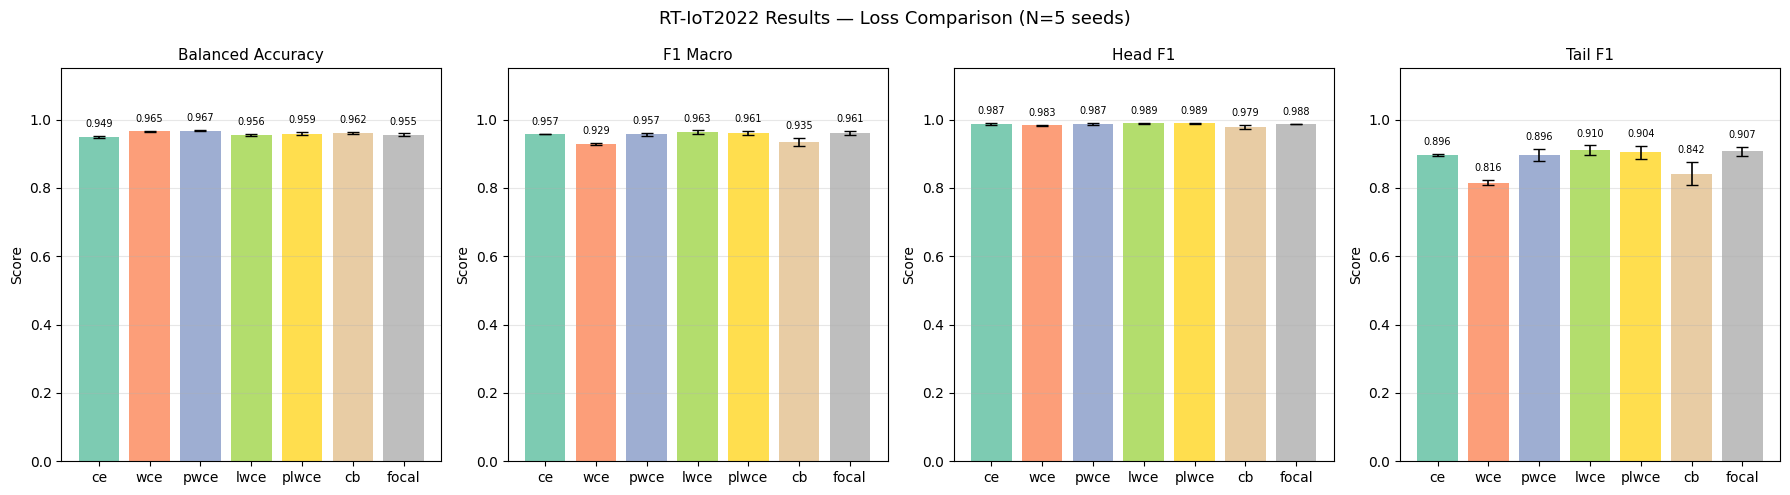

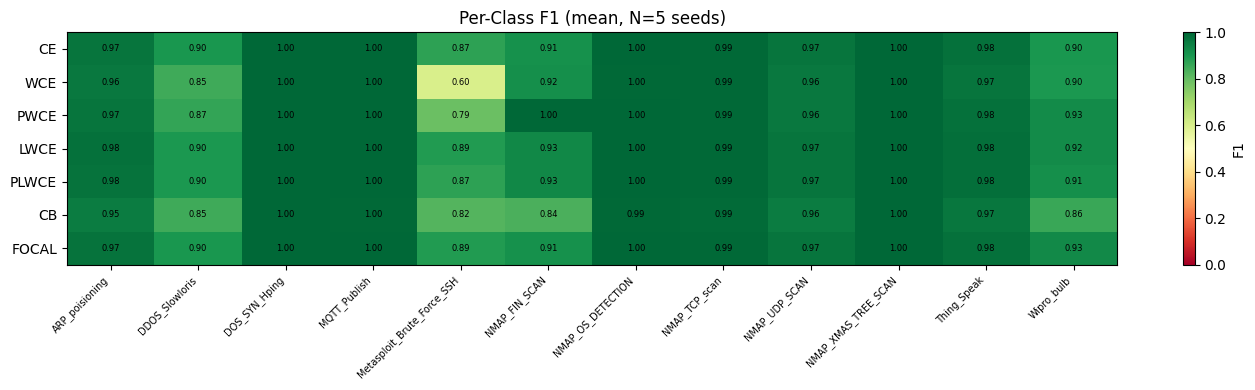

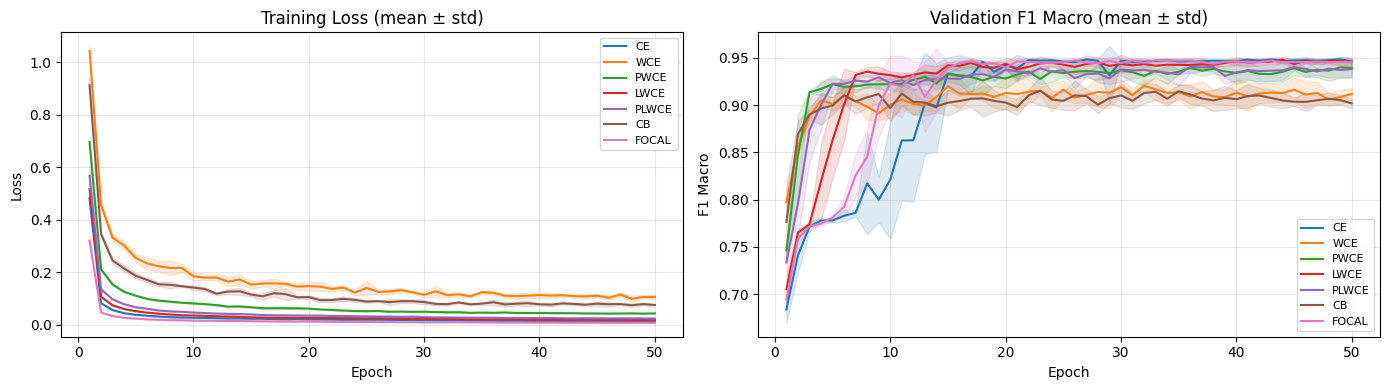

✓ Saved JSON
✓ Saved Excel

FINAL SUMMARY (mean ± std, N=5)
 Loss Balanced_Accuracy      F1_Macro       Head_F1       Tail_F1
   ce     0.9491±0.0020 0.9574±0.0010 0.9871±0.0028 0.8957±0.0029
  wce     0.9653±0.0016 0.9288±0.0032 0.9832±0.0024 0.8158±0.0070
 pwce     0.9675±0.0016 0.9565±0.0057 0.9867±0.0024 0.8955±0.0178
 lwce     0.9560±0.0029 0.9632±0.0050 0.9895±0.0010 0.9105±0.0141
plwce     0.9588±0.0045 0.9606±0.0068 0.9890±0.0010 0.9037±0.0197
   cb     0.9618±0.0028 0.9350±0.0125 0.9788±0.0051 0.8417±0.0340
focal     0.9554±0.0044 0.9612±0.0051 0.9876±0.0009 0.9068±0.0143


In [10]:
# Cell 7: Aggregate + Visualize + Save Results
METRIC_KEYS = ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Mid_F1', 'Tail_F1', 'Accuracy', 'F1_Weighted']
loss_names  = LOSS_CONFIGS

agg = {}
for ln in loss_names:
    agg[ln] = {}
    for k in METRIC_KEYS:
        vals = [r[k] for r in seed_results[ln]]
        agg[ln][k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}
    per_cls_all = np.array([r['Per_Class_F1'] for r in seed_results[ln]])
    agg[ln]['Per_Class_F1_mean'] = per_cls_all.mean(axis=0).tolist()
    agg[ln]['Per_Class_F1_std']  = per_cls_all.std(axis=0).tolist()

def ms(ln, k): return f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"

print(f"\n{'='*60}\nEXPERIMENT SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
W = 17
print(f"{'Loss':8s}  {'Bal_Acc':>{W}}  {'F1_Macro':>{W}}  {'Head_F1':>{W}}  {'Tail_F1':>{W}}")
for ln in loss_names:
    print(f"{ln:8s}  {ms(ln,'Balanced_Accuracy'):>{W}}  {ms(ln,'F1_Macro'):>{W}}  {ms(ln,'Head_F1'):>{W}}  {ms(ln,'Tail_F1'):>{W}}")

colors = plt.cm.Set2(np.linspace(0, 1, len(loss_names)))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'{DATASET_NAME} Results — Loss Comparison (N={N_SEEDS} seeds)', fontsize=13)
for ax, key, title in zip(
    axes,
    ['Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1'],
    ['Balanced Accuracy',  'F1 Macro', 'Head F1', 'Tail F1']
):
    means = [agg[ln][key]['mean'] for ln in loss_names]
    stds  = [agg[ln][key]['std']  for ln in loss_names]
    bars  = ax.bar(loss_names, means, color=colors, alpha=0.85)
    ax.errorbar(loss_names, means, yerr=stds,
                fmt='none', color='black', capsize=4, linewidth=1.2)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/results_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

per_cls_mat = np.array([agg[ln]['Per_Class_F1_mean'] for ln in loss_names])
fig, ax = plt.subplots(figsize=(max(14, NUM_CLASSES), 4))
im = ax.imshow(per_cls_mat, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(loss_names)))
ax.set_yticklabels([ln.upper() for ln in loss_names])
ax.set_title(f'Per-Class F1 (mean, N={N_SEEDS} seeds)')
plt.colorbar(im, ax=ax, label='F1')
for i in range(len(loss_names)):
    for j in range(NUM_CLASSES):
        ax.text(j, i, f'{per_cls_mat[i,j]:.2f}', ha='center', va='center', fontsize=6)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/per_class_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_x = np.arange(1, FINAL_EPOCHS + 1)
for ln in loss_names:
    loss_arr = np.array([h['train_loss']   for h in seed_histories[ln]])
    f1_arr   = np.array([h['val_F1_Macro'] for h in seed_histories[ln]])
    for ax, arr in zip(axes, [loss_arr, f1_arr]):
        m, s = arr.mean(axis=0), arr.std(axis=0)
        line, = ax.plot(epochs_x, m, label=ln.upper())
        ax.fill_between(epochs_x, m - s, m + s, alpha=0.15, color=line.get_color())
for ax, title, ylabel in zip(axes,
    ['Training Loss (mean ± std)', 'Validation F1 Macro (mean ± std)'],
    ['Loss', 'F1 Macro']):
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

fname = DATASET_NAME.lower().replace('-', '').replace(' ', '_')
results_json = {
    'metadata': {
        'dataset':      DATASET_NAME,
        'model':        'MLP (256-128-64, BatchNorm, Dropout=0.3)',
        'num_classes':  NUM_CLASSES,
        'class_names':  CLASS_NAMES,
        'final_epochs': FINAL_EPOCHS,
        'batch_size':   BATCH_SIZE,
        'n_seeds':      N_SEEDS,
        'optuna_best':  optuna_best,
        'class_counts': class_counts,
    },
    'aggregated': agg,
    'per_seed':   {ln: seed_results[ln] for ln in loss_names},
}
with open(f'{RESULTS_DIR}/{fname}_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)
print('✓ Saved JSON')

summary_rows = []
for ln in loss_names:
    row = {'Loss': ln}
    for k in METRIC_KEYS:
        row[f'{k}_mean'] = round(agg[ln][k]['mean'], 4)
        row[f'{k}_std']  = round(agg[ln][k]['std'],  4)
        row[k]           = f"{agg[ln][k]['mean']:.4f}±{agg[ln][k]['std']:.4f}"
    summary_rows.append(row)
summary_df = pd.DataFrame(summary_rows)

per_class_df = pd.DataFrame(
    {ln: agg[ln]['Per_Class_F1_mean'] for ln in loss_names},
    index=CLASS_NAMES
)

raw_rows = []
for ln in loss_names:
    for s, r in enumerate(seed_results[ln]):
        row = {'loss': ln, 'seed': s}
        for k in METRIC_KEYS:
            row[k] = r[k]
        raw_rows.append(row)

with pd.ExcelWriter(f'{RESULTS_DIR}/{fname}_results.xlsx', engine='openpyxl') as writer:
    summary_df.to_excel(writer,   sheet_name='Summary_MeanStd',  index=False)
    per_class_df.to_excel(writer, sheet_name='Per_Class_F1_Mean')
    pd.DataFrame(raw_rows).to_excel(writer, sheet_name='Per_Seed_Raw', index=False)
print('✓ Saved Excel')

print(f"\n{'='*60}\nFINAL SUMMARY (mean ± std, N={N_SEEDS})\n{'='*60}")
disp = ['Loss', 'Balanced_Accuracy', 'F1_Macro', 'Head_F1', 'Tail_F1']
print(summary_df[disp].to_string(index=False))